In [19]:
### STEP 1:IMPORT IMAGES AND LANDMARK FILES

import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import cv2
import os
from PIL import Image

os.chdir(r"C:\Users\Jason Mares\Documents\VizDezI")

out_dir = 'py_output/'
r_dir ='r_output/'

### Reference landmarks refer to Landmarks from manually registered image
### Query landmarks refer to Visium landmarks

# Read images and landmarks

paths = ["12mo_270a8", "12mo_299a3"]
query_images = [cv2.imread(str(r_dir+path+"_hires_image.png")) for path in paths]
query_landmarks = pd.read_csv(r_dir + 'Query_Reference_Landmarks_for_Visium_Data.csv', index_col=[0, 1])

reference_image = cv2.imread(r'reference\40x_Wt-317-a4_6mo_(1)_Visium_2A_nl.png')
reference_image = cv2.cvtColor(reference_image, cv2.COLOR_BGR2RGB)
reference_landmarks = pd.read_csv(r_dir + 'Reference_Landmarks_for_Spatial_Registration.csv', index_col=[0, 1])

samples=paths


2


In [20]:
# Functions that perform the alignment and image transformations

def calculate_homography_matrix(reference_coords, query_coords):
    # keep only coordinate columns
    reference_coords = reference_coords.filter(regex='V')
    query_coords = query_coords.filter(regex='V')

    # want reference coords to have full complement
    ref_isna = reference_coords.isna()
    query_isna = query_coords.isna()
    assert not any(ref_isna.iloc[0] | ref_isna.iloc[1])

    # keep only shared landmarks
    to_keep = ~(ref_isna.iloc[0] | ref_isna.iloc[1] | query_isna.iloc[0] | query_isna.iloc[1])
    reference_coords = reference_coords.loc[:, to_keep]
    query_coords = query_coords.loc[:, to_keep]

    reference_coords = reference_coords.values.transpose()
    query_coords = query_coords.values.transpose()

    return cv2.findHomography(query_coords, reference_coords, method = 0)[0], (reference_coords, query_coords)
 

def transform_points(points, mat):
    return cv2.perspectiveTransform(points.reshape(-1, 1, 2), mat).reshape(-1, 2)

# Function for dealing with image dimension syntax
def Reverse(tuples):
    new_tup = tuples[::-1]
    return new_tup

In [21]:
# STEP 2 - Image alignment and transformations

# Note even though our reference is the reference image manually annotated, we technically treat the query images as a reference, 
# since we map the reference image onto the Visium images
temp = [calculate_homography_matrix(reference_coords = query_landmarks.iloc[(2*i):(2*i+2),:],
                                    query_coords=reference_landmarks) 
        for i in list(range(len(query_images)))]

mats, coord_sets = zip(*temp)

# Transform reference images + landmarks into Visium space space
images_transformed = [cv2.warpPerspective(reference_image, mat, Reverse(img.shape)[1:3]) for img, mat in zip(query_images, mats)]
landmarks_transformed = [transform_points(landmark, mat) for (_, landmark), mat in zip(coord_sets, mats)]

nrow = len(query_images)
n_features = 16

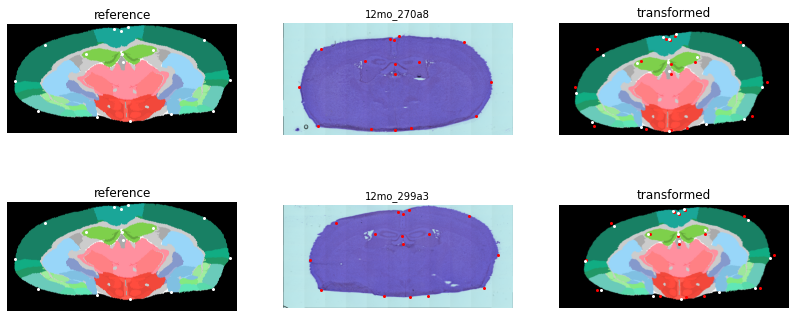

In [22]:
# STEP 3 - Display  results of transformation and registration
import re
plt.figure(figsize=(14,nrow*3))
for i, (sample, (reference_coords, query_coords), landmark_transformed, img, img_transformed) in enumerate(zip(samples,
                                                                                                               coord_sets, landmarks_transformed, query_images, images_transformed)):
# for i, (landmark, img, img_transformed, landmark_transformed) in enumerate(zip(landmarks[1:], images[1:], images_transformed, landmarks_transformed)):
    # reference image
    plt.subplot(nrow,3,3*i+1)
    plt.title('reference')
    plt.imshow(reference_image)
    plt.plot(reference_landmarks.iloc[0,:].filter(regex='V').values,
             reference_landmarks.iloc[1,:].filter(regex='V').values,'bo',c="white",markersize=2)
    plt.axis('off')

    # image to transform
    plt.subplot(nrow,3,3*i+2)
    plt.title(re.sub("_hires.png","",sample), fontsize=10)
    plt.imshow(img)
    plt.plot(query_landmarks.iloc[(2*i),:].filter(regex='V').values,
             query_landmarks.iloc[(2*i+1),:].filter(regex='V').values,'ro',markersize=2)
    plt.axis('off')

    # transformed image
    plt.subplot(nrow,3,3*i+3)
    plt.title('transformed')
    plt.imshow(img_transformed)
    plt.plot(query_landmarks.iloc[(2*i),:].filter(regex='V').values,
             query_landmarks.iloc[(2*i+1),:].filter(regex='V').values,'ro',markersize=2)
    # plt.plot(query_landmarks.iloc[(2*i),1:n_features].values,query_landmarks.iloc[(2*i+1),1:n_features].values,'ro',markersize=2)
    plt.plot(pd.DataFrame(landmark_transformed).iloc[:,0],
             pd.DataFrame(landmark_transformed).iloc[:,1],'o',c="white",markersize=2)
    plt.axis('off')
    
    # fig.set_size_inches(10, 10)
# plt.suptitle(f'Layers {layers_to_align}', y=0.9)
#plt.suptitle(f'Layers {layers_to_align}')
##plt.show()
plt.savefig(out_dir+'Spatial_Registration_v4_0.pdf', dpi =400)


<ipython-input-26-5f4dd54718f3>:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spots_coords['region'][i] = color_scheme['LABEL'][(color_scheme['R']==color[0]) & (color_scheme['G']==color[1]) & (color_scheme['B']==color[2])].values[0]
<ipython-input-26-5f4dd54718f3>:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spots_coords['region'][i] = color_scheme['LABEL'][(color_scheme['R']==color[0]) & (color_scheme['G']==color[1]) & (color_scheme['B']==color[2])].values[0]
<ipython-input-26-5f4dd54718f3>:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the d

<ipython-input-26-5f4dd54718f3>:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spots_coords['region'][i] = color_scheme['LABEL'][(color_scheme['R']==color[0]) & (color_scheme['G']==color[1]) & (color_scheme['B']==color[2])].values[0]
<ipython-input-26-5f4dd54718f3>:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spots_coords['region'][i] = color_scheme['LABEL'][(color_scheme['R']==color[0]) & (color_scheme['G']==color[1]) & (color_scheme['B']==color[2])].values[0]
<ipython-input-26-5f4dd54718f3>:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the d

<ipython-input-26-5f4dd54718f3>:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spots_coords['region'][i] = color_scheme['LABEL'][(color_scheme['R']==color[0]) & (color_scheme['G']==color[1]) & (color_scheme['B']==color[2])].values[0]
<ipython-input-26-5f4dd54718f3>:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spots_coords['region'][i] = color_scheme['LABEL'][(color_scheme['R']==color[0]) & (color_scheme['G']==color[1]) & (color_scheme['B']==color[2])].values[0]
<ipython-input-26-5f4dd54718f3>:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the d

<ipython-input-26-5f4dd54718f3>:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spots_coords['region'][i] = color_scheme['LABEL'][(color_scheme['R']==color[0]) & (color_scheme['G']==color[1]) & (color_scheme['B']==color[2])].values[0]
<ipython-input-26-5f4dd54718f3>:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spots_coords['region'][i] = color_scheme['LABEL'][(color_scheme['R']==color[0]) & (color_scheme['G']==color[1]) & (color_scheme['B']==color[2])].values[0]
<ipython-input-26-5f4dd54718f3>:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the d

<ipython-input-26-5f4dd54718f3>:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spots_coords['region'][i] = color_scheme['LABEL'][(color_scheme['R']==color[0]) & (color_scheme['G']==color[1]) & (color_scheme['B']==color[2])].values[0]
<ipython-input-26-5f4dd54718f3>:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spots_coords['region'][i] = color_scheme['LABEL'][(color_scheme['R']==color[0]) & (color_scheme['G']==color[1]) & (color_scheme['B']==color[2])].values[0]
<ipython-input-26-5f4dd54718f3>:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the d

...

<ipython-input-26-5f4dd54718f3>:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spots_coords['region'][i] = color_scheme['LABEL'][(color_scheme['R']==color[0]) & (color_scheme['G']==color[1]) & (color_scheme['B']==color[2])].values[0]
<ipython-input-26-5f4dd54718f3>:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spots_coords['region'][i] = color_scheme['LABEL'][(color_scheme['R']==color[0]) & (color_scheme['G']==color[1]) & (color_scheme['B']==color[2])].values[0]
<ipython-input-26-5f4dd54718f3>:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the d

<ipython-input-26-5f4dd54718f3>:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spots_coords['region'][i] = color_scheme['LABEL'][(color_scheme['R']==color[0]) & (color_scheme['G']==color[1]) & (color_scheme['B']==color[2])].values[0]
<ipython-input-26-5f4dd54718f3>:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spots_coords['region'][i] = color_scheme['LABEL'][(color_scheme['R']==color[0]) & (color_scheme['G']==color[1]) & (color_scheme['B']==color[2])].values[0]
<ipython-input-26-5f4dd54718f3>:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the d

<ipython-input-26-5f4dd54718f3>:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spots_coords['region'][i] = color_scheme['LABEL'][(color_scheme['R']==color[0]) & (color_scheme['G']==color[1]) & (color_scheme['B']==color[2])].values[0]
<ipython-input-26-5f4dd54718f3>:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spots_coords['region'][i] = color_scheme['LABEL'][(color_scheme['R']==color[0]) & (color_scheme['G']==color[1]) & (color_scheme['B']==color[2])].values[0]
<ipython-input-26-5f4dd54718f3>:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the d

<ipython-input-26-5f4dd54718f3>:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spots_coords['region'][i] = color_scheme['LABEL'][(color_scheme['R']==color[0]) & (color_scheme['G']==color[1]) & (color_scheme['B']==color[2])].values[0]
<ipython-input-26-5f4dd54718f3>:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spots_coords['region'][i] = color_scheme['LABEL'][(color_scheme['R']==color[0]) & (color_scheme['G']==color[1]) & (color_scheme['B']==color[2])].values[0]
<ipython-input-26-5f4dd54718f3>:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the d

<ipython-input-26-5f4dd54718f3>:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spots_coords['region'][i] = color_scheme['LABEL'][(color_scheme['R']==color[0]) & (color_scheme['G']==color[1]) & (color_scheme['B']==color[2])].values[0]
<ipython-input-26-5f4dd54718f3>:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spots_coords['region'][i] = color_scheme['LABEL'][(color_scheme['R']==color[0]) & (color_scheme['G']==color[1]) & (color_scheme['B']==color[2])].values[0]
<ipython-input-26-5f4dd54718f3>:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the d

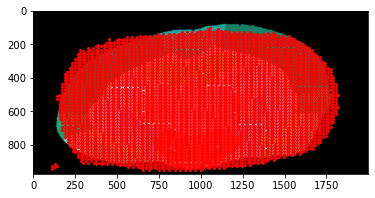

In [26]:
# STEP 4 - Link each spot to an annotation region

# create region maps for Visium images
for name, image in zip(samples,images_transformed):
    im = Image.fromarray(image)
    im.save(out_dir+name+"_hires_region.png")
    #plt.savefig(dir+"/"+title, dpi=my_dpi)
    
# Import color scheme list since each region is associated with a color
color_scheme = pd.read_csv('reference/Color_Scheme_List.csv')
color_scheme.head(10)

# Import spots center coordinates
spots_coords = pd.read_csv(r_dir+'spots_coords_hi_res.csv')
spots_coords['imagerow'] = round(spots_coords['imagerow'])
spots_coords['imagecol'] = round(spots_coords['imagecol'])
spots_coords['region'] = "root"
spots_coords[["imagerow", "imagecol"]] = spots_coords[["imagerow", "imagecol"]].astype("int")

# For each image, identify the color/region associated at each spot
for idx in range(len(samples)):

    spots_coords.loc[spots_coords['slice']==samples[idx],:]
    im = images_transformed[idx].copy()
    
    for i in range(spots_coords.shape[0]):
        if spots_coords['slice'][i]==samples[idx]:
            color = im[spots_coords['imagerow'][i],spots_coords['imagecol'][i]]
            if np.array_equal(color,np.array([0,0,0])):
                print("") 
            else:
                if len(color_scheme['LABEL'][(color_scheme['R']==color[0]) & (color_scheme['G']==color[1]) & (color_scheme['B']==color[2])]) !=0:
                    spots_coords['region'][i] = color_scheme['LABEL'][(color_scheme['R']==color[0]) & (color_scheme['G']==color[1]) & (color_scheme['B']==color[2])].values[0]


In [ ]:
# STEP 5 - Save registration results for Visium Data

plt.figure(figsize=(6,10))
plt.imshow(images_transformed[0])
plt.plot(spots_coords.imagecol.values[spots_coords['slice']==samples[0]],
         spots_coords.imagerow.values[spots_coords['slice']==samples[0]],'ro',markersize=2)
         
spots_coords.to_csv(out_dir + "spots_coords_regions.csv") 